<a href="https://colab.research.google.com/github/daffiss/machine-learning-practices/blob/main/materials/practices/p03/p03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning — Practical P03: Classification Metrics, Thresholds and Imbalance

**Course:** Machine Learning · National University of Kyiv-Mohyla Academy (NaUKMA)  
**Instructor:** Dmytro Kuzmenko · kuzmenko@ukma.edu.ua  
**Module:** 3. Learning a Boundary (Classification) · **Week 3**  
**Workload:** one practical class ≈ 1.5–2 hours of active work, including discussion  
**Status:** NOT graded — practicals are skill-development and exam-preparation sessions.  
**Prerequisites:** logistic regression, confusion matrix, train/test split

### How to work with this notebook

Every consequential task follows the loop **Experiment → Decision → Evidence → Interpretation → Counterfactual**.  
Scaffolding cells are already written and executed: read them, run them mentally, and use the printed numbers and plots as evidence.  
Empty cells are yours — they contain no model answers. The discussion questions are meant to be talked through in class.


### Learning objectives
- Read a confusion matrix and derive precision, recall, F1 and specificity by hand.
- Explain how the decision threshold trades off precision and recall.
- Compare ROC and PR curves and choose a metric for a given cost scenario.

## Warm-up (diagnostic)



**Warm-up 1.** A screening model reports **accuracy 98.4%**; the prevalence of the positive class is
**1.2%**. A majority-class baseline would score ≈ 98.8%. Which of the following is the most defensible
conclusion?

- (a) The model is excellent and ready for deployment.
- (b) Accuracy is close to the baseline, so the model adds little unless precision/recall are far
      better than the baseline — we need the confusion matrix to judge.
- (c) The model is worse than random guessing.
- (d) Accuracy should be recomputed with balanced classes before anything else.


**Your answer:**

**Warm-up 2.** A logistic-regression classifier currently uses threshold 0.5 and you move the threshold
to **0.8** (predict positive only when very confident). What happens to precision and to recall?

- (a) precision ↑, recall ↑
- **(b) precision ↑, recall ↓**
- (c) precision ↓, recall ↑
- (d) both stay the same


**Your answer:**  
Precision (Точність) ↑ зростає:
Тепер модель майже не кидається голослівними заявами. Якщо вона вже сказала «ТАК», то це практично 100% правда, помилкових спрацьовувань мінімум. Тобто якість її відповідей стала вищою.

Recall (Повнота) ↓ падає:
Через свою надмірну обережність вона промовчить там, де була впевнена, наприклад, на 60% чи 75%. А серед цих випадків було повно правильних варіантів, які вона просто побоялася назвати. Тобто більшість потрібного ми пропустили.

**Warm-up 3.** Which metric is least sensitive to a change in the *prevalence* of the positive class in
the test set: accuracy, F1, or ROC-AUC? (One-sentence answer.)


рок-аук, бо він тримається лише на двох штуках - TP i FP і зміна prevalence-у на нього найменше повпливає

**Your answer:**

## Guided Exercise — confusion matrix, thresholds, ROC vs PR

Synthetic task: fraud-like binary classification where the positive class is rare (~5%). We start from
the confusion matrix and work up to curve-based analysis.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score, ConfusionMatrixDisplay)

np.random.seed(42)
%matplotlib inline

X, y = make_classification(n_samples=5000, n_features=10, n_informative=6, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.95, 0.05], random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr, y_tr)
print(f"positive-class prevalence in test set: {y_te.mean():.3f}")


positive-class prevalence in test set: 0.049


### Task 1: The confusion matrix and derived metrics

**Experiment.** Predict at the default threshold 0.5 and display the confusion matrix.


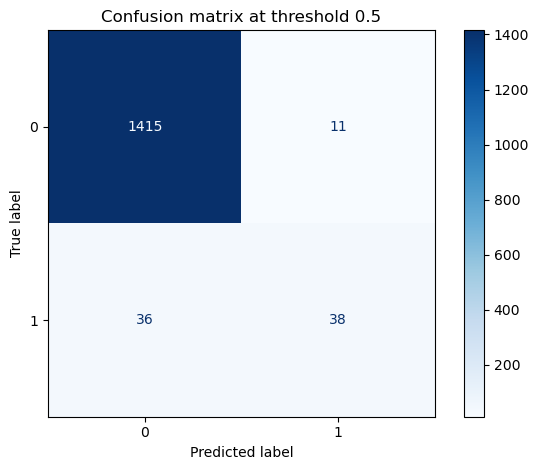

accuracy    = 0.969   (baseline majority-class accuracy = 0.951)
precision   = 0.776
recall      = 0.514
F1          = 0.618
specificity = 0.992


In [ ]:
pred = lr.predict(X_te)
ConfusionMatrixDisplay.from_predictions(y_te, pred, cmap="Blues")
plt.title("Confusion matrix at threshold 0.5")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_te, pred).ravel()
n = tn + fp + fn + tp
acc = (tp + tn) / n
specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
print(f"accuracy    = {acc:.3f}   (baseline majority-class accuracy = {max(y_te.mean(), 1 - y_te.mean()):.3f})")
print(f"precision   = {precision_score(y_te, pred):.3f}")
print(f"recall      = {recall_score(y_te, pred):.3f}")
print(f"F1          = {f1_score(y_te, pred):.3f}")
print(f"specificity = {specificity:.3f}")


**Interpretation.** The accuracy looks healthy while recall is poor. Which cell of the confusion matrix
drives accuracy here, and which metric would a stakeholder in fraud detection care about most?

**Decision.** With these numbers, is threshold 0.5 acceptable for a *screening* use case (missing a
positive is very expensive)? What about for an *alert* use case (each alert costs human review)?


**Your answer:**
 - точністю керує тут комірка TN бо там 1400 правильно взагадних. Метрика по фрауд детекштну для стейкхолдерів - думаю Recall
 - Поріг слід значно знизити (наприклад, до $0.2$ або $0.1$), щоб модель стала чутливішою, зловила практично всі позитивні кейси й мінімізувала кількість небезпечних пропусків  (На поточному порозі $0.5$ модель пропускає майже половину позитивних випадків ($FN = 36$ із $74$ реальних позитивних, $\text{Recall} \approx 51.4\%$). )

### Task 2: Threshold sweep

**Experiment.** Get the raw probabilities and compute precision, recall and F1 for many thresholds from
0.0 to 1.0.


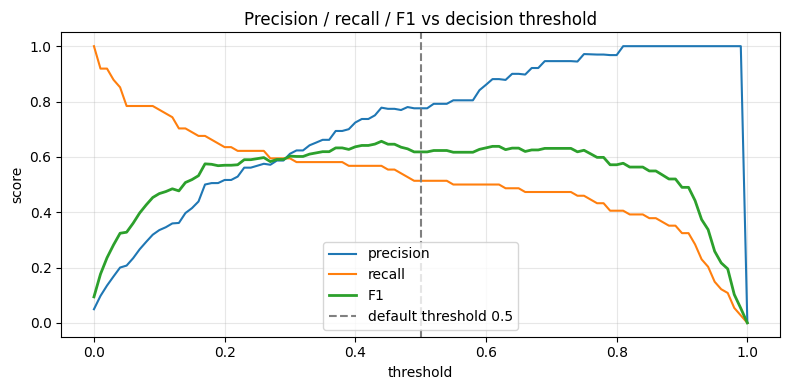

max F1 = 0.656 at threshold 0.44 (precision 0.778, recall 0.568)


In [3]:
proba = lr.predict_proba(X_te)[:, 1]
thr = np.linspace(0.0, 1.0, 101)
prec = [precision_score(y_te, proba >= t, zero_division=0) for t in thr]
rec = [recall_score(y_te, proba >= t, zero_division=0) for t in thr]
f1 = [f1_score(y_te, proba >= t, zero_division=0) for t in thr]

plt.figure(figsize=(8, 4))
plt.plot(thr, prec, label="precision")
plt.plot(thr, rec, label="recall")
plt.plot(thr, f1, label="F1", lw=2)
plt.axvline(0.5, color="gray", ls="--", label="default threshold 0.5")
plt.xlabel("threshold")
plt.ylabel("score")
plt.title("Precision / recall / F1 vs decision threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

i = np.argmax(f1)
print(f"max F1 = {f1[i]:.3f} at threshold {thr[i]:.2f} (precision {prec[i]:.3f}, recall {rec[i]:.3f})")


**Evidence.** Precision and recall move in opposite directions as the threshold slides — the trade-off
is visible, not theoretical.

**Decision.** A screening application needs recall ≥ 0.9. Read off the plot: what threshold achieves
that, and what precision do you get in exchange? Is that acceptable for your scenario?

щоб був кращий рекол, треба понизити трешхолд. думаю десь до 0.3, там де все перетинається. в обмін у нас точність буде нижча- десь 0.6-0.7. ну я думаю це аксептабл.

**Counterfactual.** Predict how the precision curve would move if the classifier were *worse*
(e.g., probabilities close to random). Would the crossover point shift left or right?

думаю якзо вони були б гірші, то пресіжн був би нижчий і не так піднімався наверх добре як тут


**Your answer:**

**Decision:** Щоб отримати $\text{recall} \ge 0.9$, поріг потрібно знизити приблизно до **$0.03$–$0.05$**, при цьому точність ($\text{precision}$) суттєво впаде — приблизно до **$0.15$–$0.20$** ($15$–$20\%$). Для сценарію скринінгу це є абсолютно прийнятним компромісом, оскільки ціна пропуску позитивного випадку критично висока, а завдання первинного етапу — відсіяти очевидну більшість норми та передати всі підозрілі об'єкти на подальшу перевірку.

**Counterfactual:** Якщо класифікатор стане гіршим (наближеним до випадкового вгадування), крива $\text{precision}$ опуститься значно нижче й не зростатиме із підвищенням порогу, наближаючись до базової частки позитивного класу (близько $0.05$). Через таке сильне просідання кривої точності точка перетину ($\text{crossover point}$) зміститься **вправо** та вниз, оскільки спадній кривій $\text{recall}$ знадобиться більший поріг, щоб опуститися до настільки низького значення.

### Task 3: ROC vs PR under a prevalence change

**Experiment.** Build a large pool of model scores (bigger synthetic dataset, same class separation),
then create three evaluation sets with prevalence 50%, 10% and 1% by subsampling negatives. Plot ROC and
PR curves for the *same* underlying classifier scores.


score pool: 1584 positives, 28416 negatives


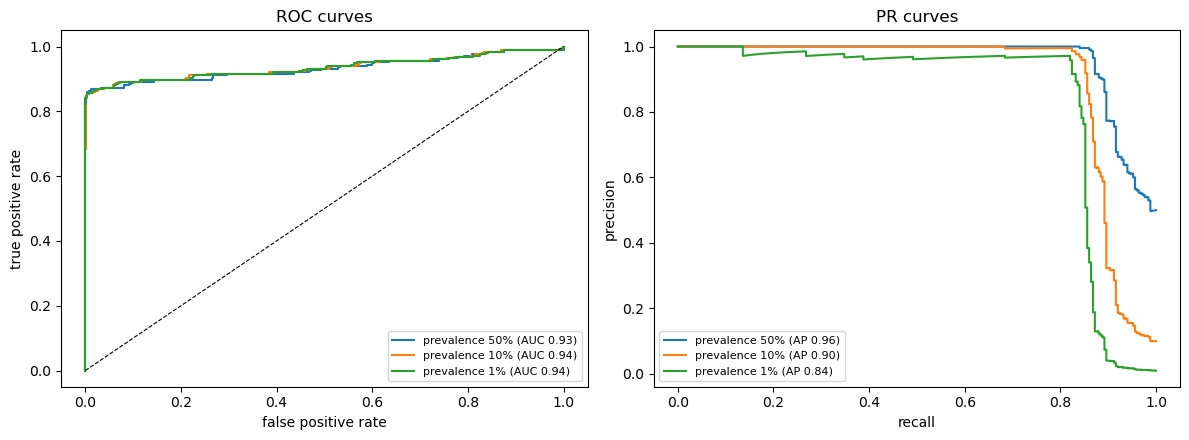

In [ ]:
# Larger score pool so that even 1% prevalence has enough negatives to sample from
X2, y2 = make_classification(n_samples=100_000, n_features=10, n_informative=6, n_redundant=0,
                             n_clusters_per_class=1, weights=[0.95, 0.05], random_state=42)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.3, random_state=42)
lr2 = LogisticRegression(max_iter=1000, random_state=42).fit(X2_tr, y2_tr)
proba_all = lr2.predict_proba(X2_te)[:, 1]
pos = proba_all[y2_te == 1]
neg = proba_all[y2_te == 0]
print(f"score pool: {len(pos)} positives, {len(neg)} negatives")

rng = np.random.RandomState(0)
n_pos = min(250, len(pos))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for prev in [0.5, 0.1, 0.01]:
    n_neg = int(n_pos * (1 - prev) / prev)
    sel_pos = pos[:n_pos]
    sel_neg = rng.choice(neg, size=n_neg, replace=False)
    y_sub = np.array([1] * n_pos + [0] * n_neg)
    p_sub = np.concatenate([sel_pos, sel_neg])

    fpr, tpr, _ = roc_curve(y_sub, p_sub)
    prec_c, rec_c, _ = precision_recall_curve(y_sub, p_sub)
    axes[0].plot(fpr, tpr, label=f"prevalence {prev:.0%} (AUC {roc_auc_score(y_sub, p_sub):.2f})")
    axes[1].plot(rec_c, prec_c, label=f"prevalence {prev:.0%} (AP {average_precision_score(y_sub, p_sub):.2f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[0].set(xlabel="false positive rate", ylabel="true positive rate", title="ROC curves")
axes[0].legend(fontsize=8)
axes[1].set(xlabel="recall", ylabel="precision", title="PR curves")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


**Evidence.** The ROC curves nearly coincide while the PR curves shift dramatically as prevalence falls.
(Note the baseline of each PR curve: it equals the prevalence itself.)

**Interpretation.** Why does PR react to prevalence and ROC (mostly) not? In which report — ROC or PR —
would a change of prevalence mislead a reader about model quality?

- ROC-крива не реагує на зміну prevalence, тому що її осі ($\text{TPR} = \frac{TP}{P}$ та $\text{FPR} = \frac{FP}{N}$) нормалізовані окремо за кожним класом і не залежать від співвідношення $P$ до $N$. Натомість у формулі $\text{Precision} = \frac{TP}{TP + FP}$ поєднуються обидва класи: при падінні prevalence негативний клас $N$ стає величезним, через що кількість $FP$ різко переважає $TP$, катастрофічно знижуючи точність.   Саме ROC-звіт введе читача в оману.

**Decision.** You must advertise one summary number to a hospital director. Which curve do you show and
why?

-  я б показала pr-криву, бо вона показує реальні дані і показники


**Your answer:**

### Task 4: Choosing a metric for a cost scenario

For each scenario below, name the metric you would optimize (or the constraint you would impose) and
justify in one or two sentences.

- **Scenario A.** Newborn hearing screening: false negatives mean a missed diagnosis; false positives
  cause a cheap retest.
- **Scenario B.** Spam filter on a personal mailbox: a false negative is an annoyance; a false positive
  can delete an important message permanently.
- **Scenario C.** Credit-card fraud: 1M transactions/month, ~1,000 frauds; each fraud ≈ $100 loss, each
  manual review ≈ $5 of analyst time, and the team can review at most 5,000 transactions/month.


**Your answer (A):** Оптимізувати метрику **Recall (Sensitivity)** або максимізувати $F_\beta$-score з вагою на повноту (наприклад, $F_2$), прагнучи мінімізувати False Negatives ($FN$). Пропуск діагнозу порушення слуху в немовляти має непоправні наслідки для його подальшого розвитку, тоді як хибне спрацьовування ($FP$) несе мінімальні витрати у вигляді швидкого та дешевого повторного тесту, тому система має виявляти якомога більше реальних патологій навіть ціною зайвих перевірок.

**Your answer (B):** Оптимізувати метрику **Precision** або накласти жорстке обмеження на False Positive Rate (наприклад, встановити допустимий поріг $\text{Precision} \ge 99.9\%$), щоб мінімізувати помилкові спрацьовування ($FP$). Хибне видалення важливого робочого чи особистого листа є критичною і незворотною втратою для користувача, тоді як пропуск окремого спам-повідомлення у вхідні ($FN$) спричиняє лише дрібну тимчасову незручність, яку легко виправити вручну за одну секунду.

**Your answer (C):** Оптимізувати **сумарний фінансовий ефект (Net Savings)** або метрику **Recall@K при $K = 5\,000$** із жорстким обмеженням на максимальну кількість перевірок ($\text{Total Alerts} \le 5\,000$ на місяць). Цільова функція має максимізувати збережені кошти за формулою $\text{Savings} = \$100 \times TP - \$5 \times (TP + FP)$, обираючи рівно топ-$5\,000$ найбільш ризикових транзакцій, щоб не перевищити фізичний ліміт робочого часу команди аналітиків і водночас нейтралізувати якомога більше фінансових втрат від шахрайства.

## Discussion Questions

1. Accuracy is the most reported metric in business dashboards. Give the precise conditions under which
   accuracy is a faithful summary, and one realistic counterexample from your own experience.
2. Why does F1 use the *harmonic* mean of precision and recall rather than the arithmetic mean?
3. ROC-AUC is prevalence-independent — is it therefore always the right summary for an imbalanced
   problem? Where does it fail (think of very skewed scores or extreme prevalence)?
4. Write down the expected cost of a decision rule as a function of TP/FP/TN/FN counts and unit costs.
   What threshold would you pick if a false positive costs 10× a false negative?
5. Two models: model 1 has higher ROC-AUC, model 2 has higher precision at recall = 0.8. Which one
   would you deploy for a screening program with a fixed review budget?
6. A colleague reports "F1 = 0.87" with no threshold or prevalence. What questions do you ask before
   trusting it?


## Challenge — should we deploy the fraud detector?

**Scenario.** A fraud detector scores all 1M monthly transactions. At threshold 0.5 it achieves
**precision 0.90, recall 0.20** on the last month's data. There are ~1,000 frauds per month. Each
detected fraud saves $100 (recovery + prevented loss); each false alarm costs $5 of analyst time
(10 minutes at $30/hour). The team has no budget cap on analyst time.

The constants are defined below — **your task** is to compute the monthly net value at threshold 0.5,
decide whether deployment at that threshold makes sense, and say which threshold you would explore next
and why (threshold sweep → higher recall or higher precision?).


In [ ]:
n_monthly = 1_000_000     # transactions per month
frauds_monthly = 1000       # true frauds
precision_05 = 0.90
recall_05 = 0.20
value_per_detected = 100.0  # USD saved per detected fraud
cost_per_fp = 5.0           # USD per false alarm

# Derived quantities (TP = detected frauds, FP = false alarms)
tp = recall_05 * frauds_monthly
fp = tp / precision_05 - tp
print(f"TP (detected frauds): {tp:.0f}")
print(f"FP (false alarms):    {fp:.0f}")


TP (detected frauds): 200
FP (false alarms):    22


**Your task.**
1. Compute monthly saved value, monthly false-alarm cost, and the **net** value at threshold 0.5.
2. Decide: deploy at 0.5, or explore a different threshold first? Justify with the numbers.
3. **Counterfactual:** the same model at a lower threshold gives precision 0.50, recall 0.70.
   Compute the net value for that operating point. Which of the two would you choose?
4. What additional *evidence* (plot or metric) would you produce to support the final decision?


In [ ]:
# Your code here — expected-value computation for both operating points


**Your answer (decision and counterfactual analysis):**

## Takeaways

- Accuracy is uninterpretable without the baseline and the confusion matrix; on imbalanced data it is
  usually dominated by the majority class.
- Precision and recall trade off through the threshold; the *right* threshold is a cost decision, not a
  statistical one.
- F1 is a single summary of the precision–recall balance; it ignores true negatives (and thus
  specificity) — say what you lose when using it.
- ROC curves are (mostly) prevalence-independent; PR curves are not. Report PR when the positive class
  is rare and you care about its detection.
- Expected cost = value of TP − cost of FP − cost of FN (plus fixed costs) — decide thresholds with
  arithmetic, not vibes.
- Every reported metric needs its context: threshold, prevalence, and the baseline of the chosen metric.
